# Customer Segmentation & Clustering (K-Means & PCA)

## 1. Unsupervised Segmentation
In this phase, we group prospective plot buyers using **K-Means Clustering** and visualize clusters using **Principal Component Analysis (PCA)**.
Buyer personas identified:
1: **Conservative Value Seekers**
2: **Young Starter Buyers**
3: **High-Intent Mid-Career Upgraders**
4: **Affluent Luxury Investors**

In [6]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


df = pd.read_csv("C:/code/IBM Training/Project/Real_estate/real-estate-prediction/data/processed/cleaned_users.csv")

features = [
    "Age",
    "Monthly_Income",
    "Plot_Budget",
    "Preferred_Plot_Size_SqFt",
    "Distance_to_City_Center_km",
    "Purchase_Probability"
]

# Replace invalid sentinel budget with missing value
SENTINEL = 999999999
df["Plot_Budget"] = df["Plot_Budget"].replace(SENTINEL, np.nan)

# Remove records with invalid Plot_Budget for clustering
df_clean = df.dropna(subset=["Plot_Budget"]).copy()

# Select clustering features
X = df_clean[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized.")
print(f"Original records: {len(df)}")
print(f"Records used for clustering: {len(df_clean)}")
print(f"Records excluded: {len(df) - len(df_clean)}")


Features standardized.
Original records: 12000
Records used for clustering: 11934
Records excluded: 66


## 2. Elbow Method for Optimal Clusters

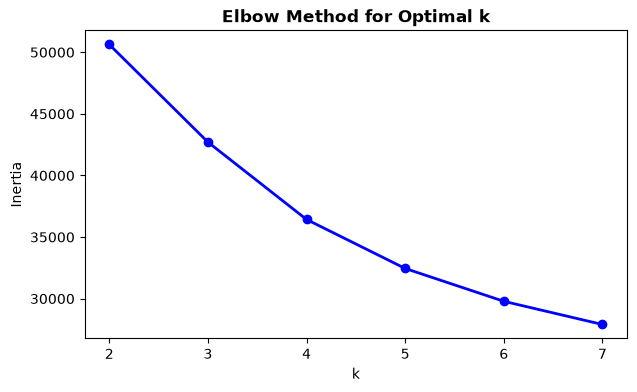

In [7]:
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.title("Elbow Method for Optimal k", fontweight='bold')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()


### 2.1 Silhouette Score & Davies-Bouldin Index 

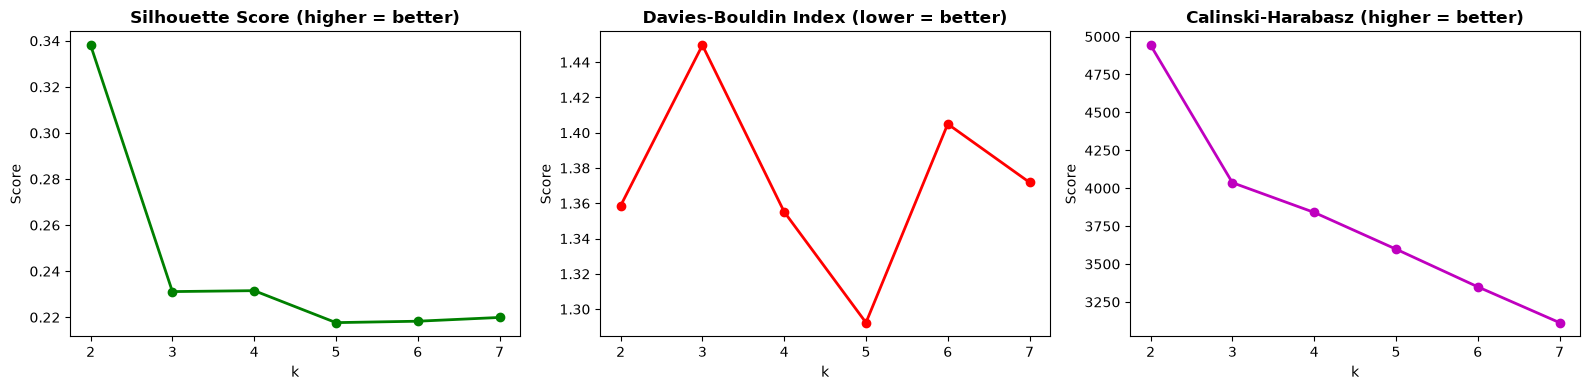

Best k by Silhouette: 2
Best k by Davies-Bouldin: 5
Best k by Calinski-Harabasz: 2


In [8]:


sil_scores, db_scores, ch_scores = [], [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_range, sil_scores, 'go-', linewidth=2)
axes[0].set_title("Silhouette Score (higher = better)", fontweight='bold')
axes[0].set_xlabel("k"); axes[0].set_ylabel("Score")

axes[1].plot(K_range, db_scores, 'ro-', linewidth=2)
axes[1].set_title("Davies-Bouldin Index (lower = better)", fontweight='bold')
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")

axes[2].plot(K_range, ch_scores, 'mo-', linewidth=2)
axes[2].set_title("Calinski-Harabasz (higher = better)", fontweight='bold')
axes[2].set_xlabel("k"); axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

print(f"Best k by Silhouette: {list(K_range)[np.argmax(sil_scores)]}")
print(f"Best k by Davies-Bouldin: {list(K_range)[np.argmin(db_scores)]}")
print(f"Best k by Calinski-Harabasz: {list(K_range)[np.argmax(ch_scores)]}")

## 2.2 Cluster Evaluation Summary Table (k=2 to 6)

In [9]:


k_range = range(2, 7)
results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)  # swap to X_scaled_clean once outlier fix is in
    results.append({
        "k": k,
        "Inertia": round(km.inertia_, 2),
        "Silhouette": round(silhouette_score(X_scaled, labels), 4),
        "Davies-Bouldin": round(davies_bouldin_score(X_scaled, labels), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_scaled, labels), 2),
    })

summary_table = pd.DataFrame(results).set_index("k")
summary_table

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,50629.83,0.3381,1.3586,4943.03
3,42707.11,0.2311,1.4496,4036.43
4,36426.73,0.2315,1.3552,3840.27
5,32450.31,0.2177,1.2924,3598.32
6,29784.04,0.2183,1.4050,3349.64


## 3. Two-Stage K-Means Segmentation (Macro → Sub-Persona)
### 3.1 Stage 1: Macro-Segment Split (k=2, statistically optimal)

In [10]:


km_macro = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clean['Macro_Segment'] = km_macro.fit_predict(X_scaled)

macro_summary = df_clean.groupby('Macro_Segment')[features].mean().round(2)
print("Macro Segment Centroid Summary:")
print(macro_summary)

macro_sizes = df_clean['Macro_Segment'].value_counts()
print("\nMacro Segment Sizes:")
print(macro_sizes)

macro_sil = silhouette_score(X_scaled, df_clean['Macro_Segment'])
print(f"\nStage 1 Silhouette Score: {macro_sil:.4f}")

Macro Segment Centroid Summary:
                 Age  Monthly_Income  Plot_Budget  Preferred_Plot_Size_SqFt  \
Macro_Segment                                                                 
0              34.99        90400.87   4182379.36                   1074.06   
1              48.58       277607.73  11723390.75                   1973.09   

               Distance_to_City_Center_km  Purchase_Probability  
Macro_Segment                                                    
0                                   23.38                  0.41  
1                                   23.44                  0.42  

Macro Segment Sizes:
Macro_Segment
0    8973
1    2961
Name: count, dtype: int64

Stage 1 Silhouette Score: 0.3381


### 3.2 Stage 2: Sub-Cluster Each Macro Segment into 2 Personas

In [11]:
df_clean['Sub_Segment'] = -1
sub_models = {}

for seg in sorted(df_clean['Macro_Segment'].unique()):
    mask = df_clean['Macro_Segment'] == seg
    X_seg = X_scaled[mask.values]

    km_sub = KMeans(n_clusters=2, random_state=42, n_init=10)
    sub_labels = km_sub.fit_predict(X_seg)
    sub_models[seg] = km_sub

    sub_sil = silhouette_score(X_seg, sub_labels)
    print(f"Macro Segment {seg} -> Sub-cluster Silhouette: {sub_sil:.4f}")

    df_clean.loc[mask, 'Sub_Segment'] = sub_labels

df_clean['Final_Cluster'] = (
    df_clean['Macro_Segment'].astype(str) + "_" + df_clean['Sub_Segment'].astype(str)
)

print("\nFinal 4-Way Cluster Sizes:")
print(df_clean['Final_Cluster'].value_counts())

Macro Segment 0 -> Sub-cluster Silhouette: 0.2652
Macro Segment 1 -> Sub-cluster Silhouette: 0.3580

Final 4-Way Cluster Sizes:
Final_Cluster
0_1    5776
0_0    3197
1_1    2369
1_0     592
Name: count, dtype: int64


### 3.3 Final Cluster Profiling

In [12]:
final_summary = df_clean.groupby('Final_Cluster')[features].mean().round(2)
print("Final Cluster Centroid Summary:")
print(final_summary)

print("\nFinal Cluster Size (%):")
print((df_clean['Final_Cluster'].value_counts(normalize=True) * 100).round(2))

Final Cluster Centroid Summary:
                 Age  Monthly_Income  Plot_Budget  Preferred_Plot_Size_SqFt  \
Final_Cluster                                                                 
0_0            35.51        92139.76   4225430.09                   1075.36   
0_1            34.70        89438.40   4158550.90                   1073.34   
1_0            49.86       449291.72  20485675.68                   2808.96   
1_1            48.26       234704.85   9533744.20                   1764.22   

               Distance_to_City_Center_km  Purchase_Probability  
Final_Cluster                                                    
0_0                                 22.60                  0.84  
0_1                                 23.81                  0.18  
1_0                                 24.06                  0.38  
1_1                                 23.28                  0.43  

Final Cluster Size (%):
Final_Cluster
0_1    48.40
0_0    26.79
1_1    19.85
1_0     4.96
Name: 

### 3.4 Persona Mapping on Final Clusters

In [13]:

persona_map_final = {}

for c in df_clean['Final_Cluster'].unique():
    row = final_summary.loc[c]
    if row['Plot_Budget'] > final_summary['Plot_Budget'].median() * 1.5:
        persona_map_final[c] = "Affluent Luxury Investors"
    elif row['Purchase_Probability'] > final_summary['Purchase_Probability'].median():
        if row['Age'] < final_summary['Age'].median():
            persona_map_final[c] = "Young Starter Buyers"
        else:
            persona_map_final[c] = "High-Intent Mid-Career Upgraders"
    else:
        persona_map_final[c] = "Conservative Value Seekers"

df_clean['Persona'] = df_clean['Final_Cluster'].map(persona_map_final)

print("Cluster -> Persona Mapping:")
for c, p in persona_map_final.items():
    print(f"  {c}: {p}")

print("\nFinal Persona Distribution (%):")
print((df_clean['Persona'].value_counts(normalize=True) * 100).round(2))

Cluster -> Persona Mapping:
  0_1: Conservative Value Seekers
  0_0: Young Starter Buyers
  1_1: High-Intent Mid-Career Upgraders
  1_0: Affluent Luxury Investors

Final Persona Distribution (%):
Persona
Conservative Value Seekers          48.40
Young Starter Buyers                26.79
High-Intent Mid-Career Upgraders    19.85
Affluent Luxury Investors            4.96
Name: proportion, dtype: float64


### 3.5 Cluster Stability Check — Stage 1 Macro-Segment (multiple seeds)

In [14]:

seeds = [0, 1, 42, 123, 2024]
labels_by_seed = {}

for s in seeds:
    km = KMeans(n_clusters=2, random_state=s, n_init=10)
    labels_by_seed[s] = km.fit_predict(X_scaled)

print("Pairwise ARI for Macro Segment (k=2) across seeds:")
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(labels_by_seed[seeds[i]], labels_by_seed[seeds[j]])
        print(f"  seed {seeds[i]} vs seed {seeds[j]}: ARI = {ari:.3f}")

Pairwise ARI for Macro Segment (k=2) across seeds:
  seed 0 vs seed 1: ARI = 0.994
  seed 0 vs seed 42: ARI = 0.994
  seed 0 vs seed 123: ARI = 0.995
  seed 0 vs seed 2024: ARI = 0.994
  seed 1 vs seed 42: ARI = 1.000
  seed 1 vs seed 123: ARI = 0.999
  seed 1 vs seed 2024: ARI = 1.000
  seed 42 vs seed 123: ARI = 0.999
  seed 42 vs seed 2024: ARI = 1.000
  seed 123 vs seed 2024: ARI = 0.999


### 3.2 Hierarchical Clustering Cross-Check (Stage 1 vs Dendrogram)

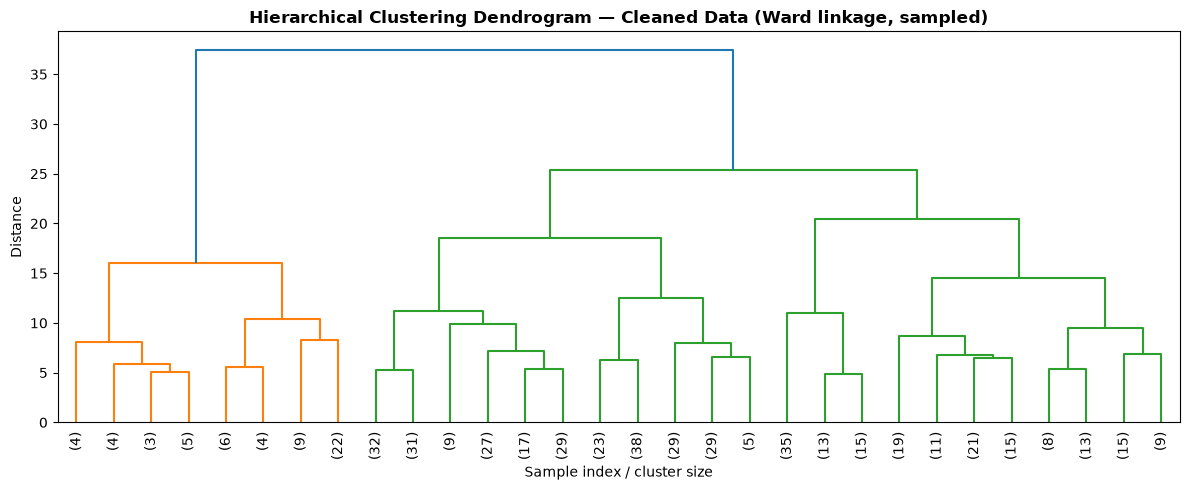

ARI between Macro Segment (k=2) and Hierarchical (k=2): 0.521


In [15]:
## 3.2 Hierarchical Clustering Cross-Check (Stage 1 vs Dendrogram)

sample_idx = np.random.RandomState(42).choice(len(X_scaled), 500, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram — Cleaned Data (Ward linkage, sampled)", fontweight='bold')
plt.xlabel("Sample index / cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

hier_labels = fcluster(Z, t=2, criterion='maxclust')
macro_labels_sample = df_clean['Macro_Segment'].values[sample_idx]
ari_hier_vs_macro = adjusted_rand_score(macro_labels_sample, hier_labels)
print(f"ARI between Macro Segment (k=2) and Hierarchical (k=2): {ari_hier_vs_macro:.3f}")

## 4. PCA 2D Cluster Projection

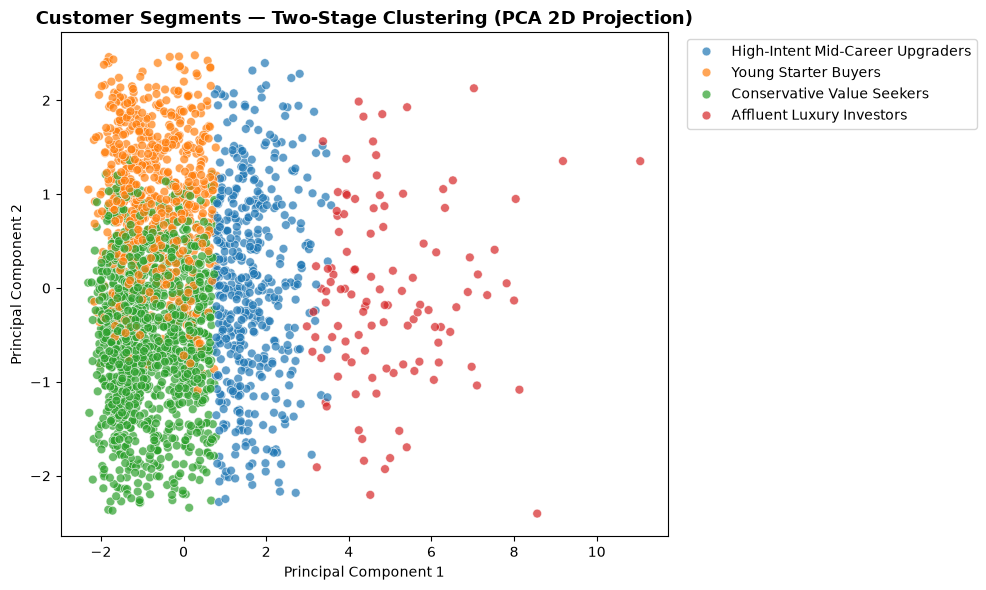

PC1 + PC2 explain 64.5% of total variance


In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean.sample(min(2500, len(df_clean)), random_state=42),
    x='PCA1',
    y='PCA2',
    hue='Persona',
    palette='tab10',
    alpha=0.7,
    s=40
)
plt.title("Customer Segments — Two-Stage Clustering (PCA 2D Projection)", fontsize=13, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")


### 4.1 PCA Explained Variance (how much are we actually seeing in 2D?)

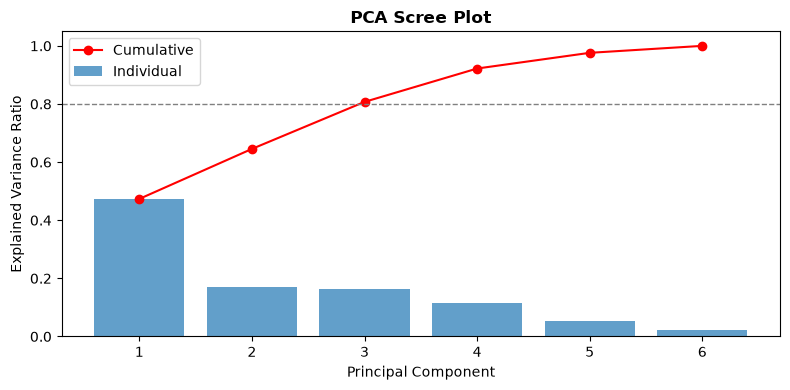

PC1 + PC2 explain 64.5% of total variance


In [17]:
pca_full = PCA(n_components=len(features), random_state=42)
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(features) + 1), pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(range(1, len(features) + 1), np.cumsum(pca_full.explained_variance_ratio_),
         'ro-', label='Cumulative')
plt.axhline(y=0.8, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")

### 5.1 Statistical Significance of Cluster Differences

In [18]:
from scipy.stats import f_oneway

print("One-way ANOVA — is each feature significantly different across clusters?\n")
for feat in features:
    groups = [df_clean.loc[df_clean['Final_Cluster'] == c, feat] for c in sorted(df_clean['Final_Cluster'].unique())]
    f_stat, p_val = f_oneway(*groups)
    sig = "significant" if p_val < 0.05 else "NOT significant"
    print(f"{feat:30s}  F={f_stat:8.2f}   p={p_val:.4e}   ({sig})")

One-way ANOVA — is each feature significantly different across clusters?

Age                             F= 1649.51   p=0.0000e+00   (significant)
Monthly_Income                  F= 8469.69   p=0.0000e+00   (significant)
Plot_Budget                     F= 8602.68   p=0.0000e+00   (significant)
Preferred_Plot_Size_SqFt        F= 5843.50   p=0.0000e+00   (significant)
Distance_to_City_Center_km      F=    9.16   p=4.7407e-06   (significant)
Purchase_Probability            F= 6561.48   p=0.0000e+00   (significant)


### 5.2 Cluster Profile Visualization (boxplots per feature)

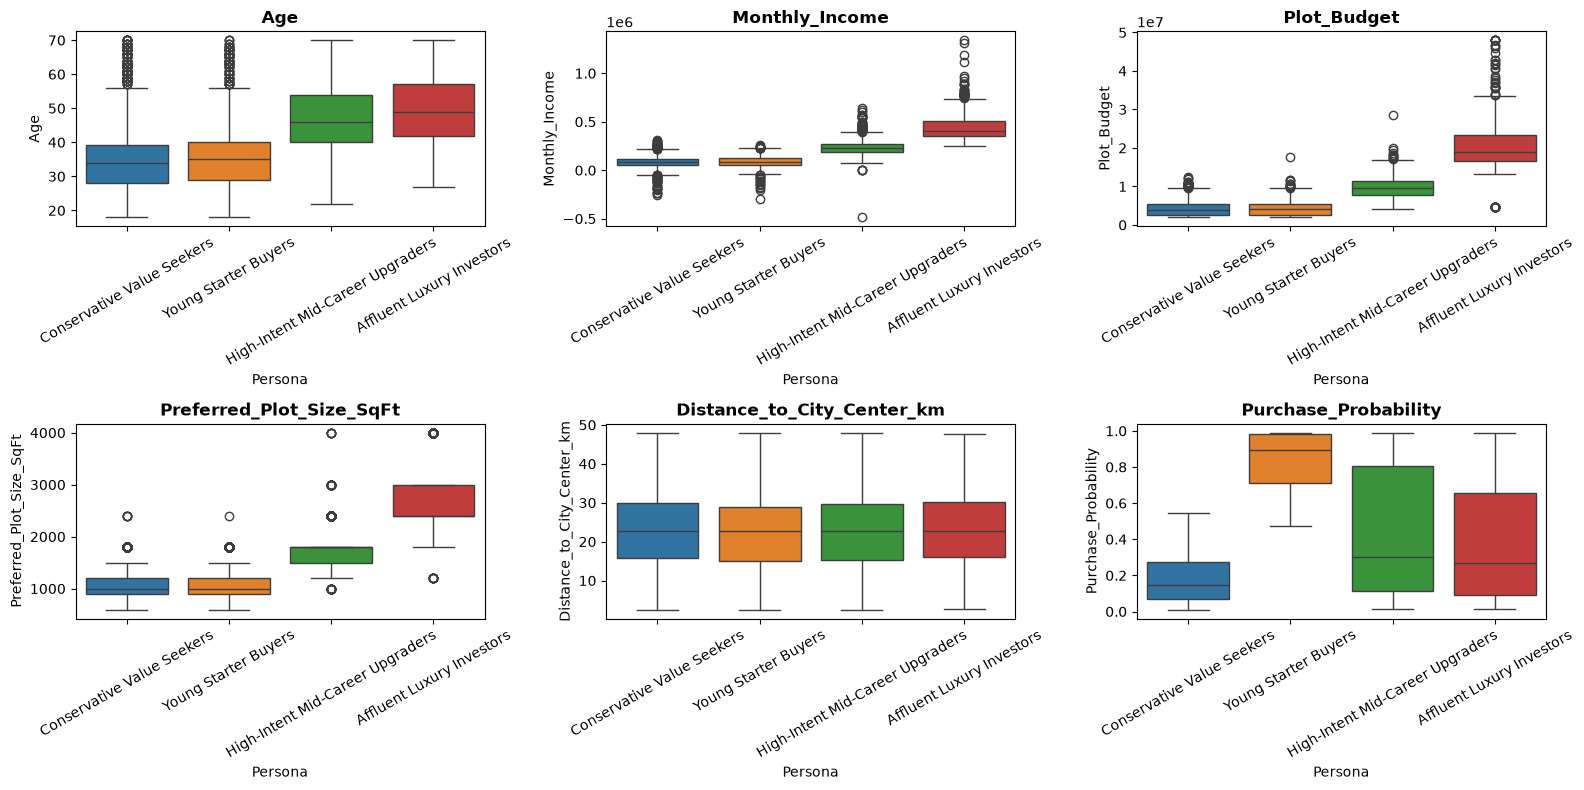

In [19]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df_clean, x='Persona', y=feat, ax=axes[i], palette='tab10')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 6.1 What Drives Each Persona? (Random Forest feature importance)

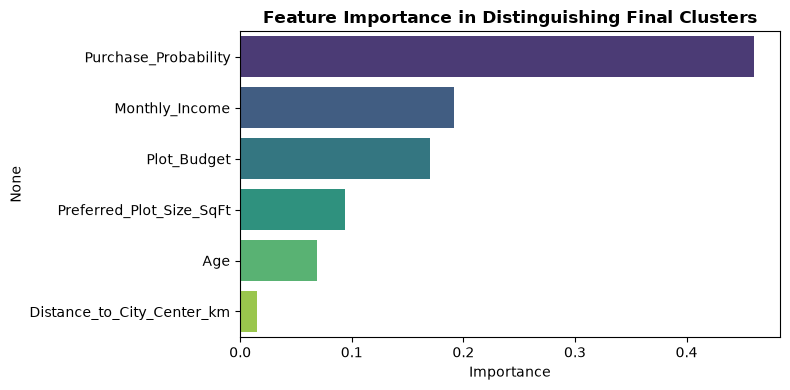

Purchase_Probability          0.461
Monthly_Income                0.191
Plot_Budget                   0.170
Preferred_Plot_Size_SqFt      0.094
Age                           0.069
Distance_to_City_Center_km    0.015
dtype: float64


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_scaled, df_clean['Final_Cluster'])

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance in Distinguishing Final Clusters", fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.round(3))